# Overview

This notebook implements a Bayesian hierarchical panel model to analyze Life Expectancy gender gaps, replicating the PyMC model in `bayesian_model_py.md` using `brms`.

**Model Structure:** 
- Random intercepts by country (37 OECD countries, Turkey excluded)
- Shared slopes for 11-12 Gap predictors
- Panel data: ~888 observations (37 countries × 24 years)
- **Explicit preprocessing**: Standardized predictors (mean=0, std=1, population std), centered target
- **Priors**: Normal(0,1) for predictor coefficients (matching PyMC, not horseshoe)

**Data source:** Panel data from `process.ipynb` (CSV format)

# Setup

In [70]:
library(tidyverse)
library(brms)
library(bayesplot)
library(loo)
library(tidybayes)
library(posterior)
library(patchwork)

# Set theme
theme_set(theme_minimal(base_size = 12))

# Set bayesplot color scheme
color_scheme_set("brightblue")

# For reproducibility
set.seed(42)

# Use all available cores
options(mc.cores = parallel::detectCores())

In [71]:
# Logging functions (similar to Python's log_and_print)
# Global log file connection (set by set_log_file)
.log_file <- NULL

# Set the global log file
set_log_file <- function(log_path) {
  if (!is.null(.log_file)) {
    close(.log_file)
  }
  .log_file <<- file(log_path, "w")
  cat("Logging to:", log_path, "\n")
  return(.log_file)
}

# Log and print message (writes to both log file and console)
# Accepts sprintf-style formatting: log_and_print("Value: %d", x)
log_and_print <- function(fmt, ...) {
  # Format message using sprintf if additional arguments provided
  if (length(list(...)) > 0) {
    message <- sprintf(fmt, ...)
  } else {
    message <- fmt
  }
  
  # Write to log file if it's open
  if (!is.null(.log_file) && isOpen(.log_file)) {
    writeLines(message, .log_file)
    flush(.log_file)
  }
  # Print to console
  cat(message, "\n")
}

# Close log file (call at end of notebook or in cleanup)
close_log_file <- function() {
  if (!is.null(.log_file) && isOpen(.log_file)) {
    close(.log_file)
    .log_file <<- NULL
    cat("Log file closed.\n")
  }
}

# Setup log file
dir.create("logs", showWarnings = FALSE, recursive = TRUE)
log_path <- "logs/bayesian_model_r_brms.txt"
set_log_file(log_path)

# Log header
log_and_print(paste0(rep("=", 80), collapse = ""))
log_and_print("BAYESIAN PANEL MODEL - LIFE EXPECTANCY GENDER GAPS (R/brms)")
log_and_print(paste0(rep("=", 80), collapse = ""))
log_and_print(paste("Timestamp:", Sys.time()))
log_and_print(paste0(rep("=", 80), collapse = ""))

Logging to: logs/bayesian_model_r_brms.txt 


A connection with                                            
description "logs/bayesian_model_r_brms.txt"
class       "file"                          
mode        "w"                             
text        "text"                          
opened      "opened"                        
can read    "no"                            
can write   "yes"                           

BAYESIAN PANEL MODEL - LIFE EXPECTANCY GENDER GAPS (R/brms) 
Timestamp: 2026-01-28 16:39:06.94796 


# Load Data

The panel dataset is created by `process.ipynb` and saved to CSV.

In [72]:
# Load panel data from CSV (created by process.ipynb)
csv_path <- "../data/panel_le.csv"

if (!file.exists(csv_path)) {
  stop("Panel data not found at ", csv_path, "\n",
       "Please run process.ipynb first to create the panel data.")
}

panel <- read_csv(csv_path, show_col_types = FALSE)

log_and_print(paste0("\n", paste0(rep("=", 80), collapse = "")))
log_and_print("PANEL DATA LOADED")
log_and_print(paste0(rep("=", 80), collapse = ""))
log_and_print("Source: %s", csv_path)
log_and_print("Shape: %d x %d", nrow(panel), ncol(panel))
log_and_print("Countries: %d", n_distinct(panel$country))
log_and_print("Years: %d-%d", min(panel$Year), max(panel$Year))
log_and_print("Missing values: %d", sum(is.na(panel)))
log_and_print(paste0(rep("=", 80), collapse = ""))


PANEL DATA LOADED 
Source: ../data/panel_le.csv 
Shape: 888 x 27 
Countries: 37 
Years: 2000-2023 
Missing values: 0 


In [73]:
glimpse(panel)

Rows: 888
Columns: 27
$ country                 <chr> "AUS", "AUS", "AUS", "AUS", "AUS", "AUS", "AUS…
$ Year                    <dbl> 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007…
$ LE_gap                  <dbl> 5.3258, 5.2164, 4.9902, 4.9644, 4.9009, 4.8024…
$ Mid_Alcohol             <dbl> 1.683177, 1.633888, 1.692577, 1.683623, 1.6654…
$ Gap_Alcohol             <dbl> 2.103379, 2.035051, 2.040075, 2.005382, 1.9226…
$ Mid_Suicide             <dbl> 13.62992, 13.24545, 12.52106, 11.87477, 11.535…
$ Gap_Suicide             <dbl> 16.00476, 15.13518, 14.07272, 13.44912, 13.224…
$ Mid_Homicide            <dbl> 1.7337785, 1.6848733, 1.5879957, 1.3851044, 1.…
$ Gap_Homicide            <dbl> 1.026409395, 1.058053696, 1.014457891, 0.99046…
$ Mid_RoadTraffic         <dbl> 10.634210, 10.228433, 9.767470, 9.220344, 8.91…
$ Gap_RoadTraffic         <dbl> 9.100231, 8.891709, 8.444396, 8.019510, 8.0333…
$ Mid_Cardiovascular      <dbl> 255.5133, 249.6689, 249.1729, 240.4196, 231.83…
$ Gap_Cardiovascul

In [74]:
# Data summary
log_and_print("Panel Data Summary:")
log_and_print("  Observations: %d", nrow(panel))
log_and_print("  Countries: %d", n_distinct(panel$country))
log_and_print("  Years: %d-%d", min(panel$Year), max(panel$Year))
log_and_print("  Missing values: %d", sum(is.na(panel)))

# Target variable summary
log_and_print("\nLife Expectancy Gap (Female - Male):")
log_and_print("  Mean: %.2f years", mean(panel$LE_gap))
log_and_print("  SD: %.2f years", sd(panel$LE_gap))
log_and_print("  Range: %.2f to %.2f years", min(panel$LE_gap), max(panel$LE_gap))

Panel Data Summary: 
  Observations: 888 
  Countries: 37 
  Years: 2000-2023 
  Missing values: 0 

Life Expectancy Gap (Female - Male): 
  Mean: 5.72 years 
  SD: 1.87 years 
  Range: 2.55 to 12.67 years 


# Exploratory Analysis

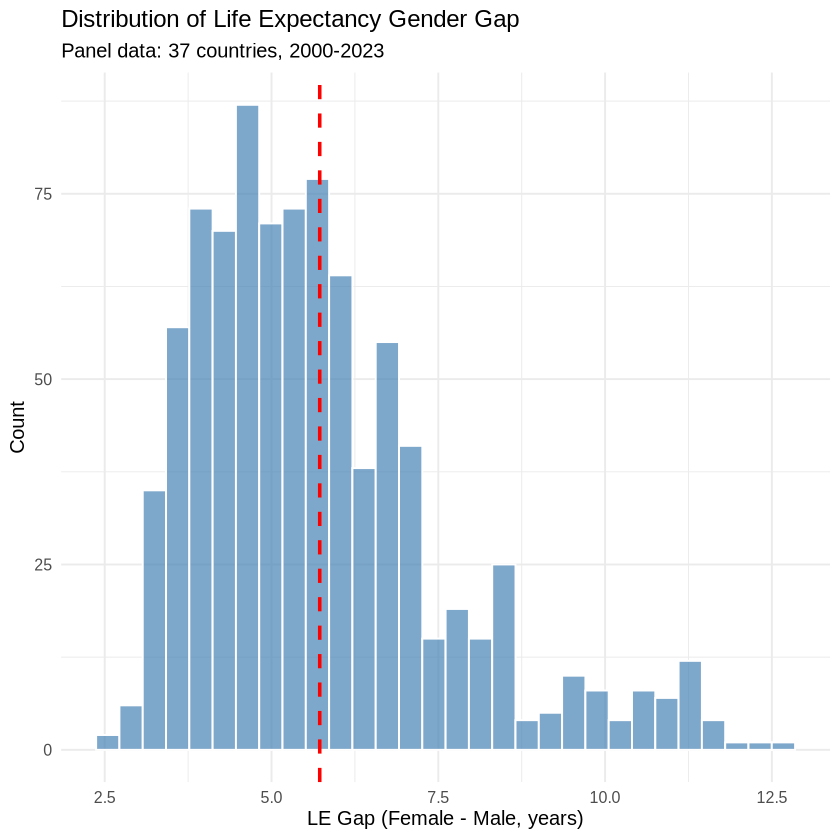

In [75]:
# Distribution of target variable
ggplot(panel, aes(x = LE_gap)) +
  geom_histogram(bins = 30, fill = "steelblue", color = "white", alpha = 0.7) +
  geom_vline(xintercept = mean(panel$LE_gap), color = "red", linetype = "dashed", linewidth = 1) +
  labs(
    title = "Distribution of Life Expectancy Gender Gap",
    subtitle = sprintf("Panel data: %d countries, %d-%d", 
                       n_distinct(panel$country), min(panel$Year), max(panel$Year)),
    x = "LE Gap (Female - Male, years)",
    y = "Count"
  )

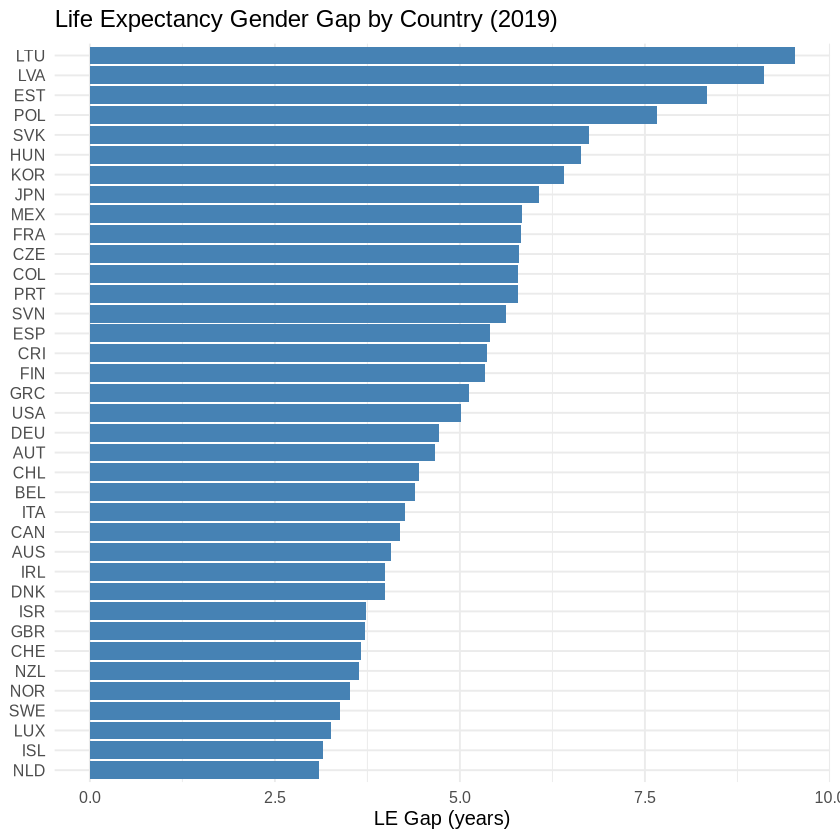

In [76]:
# LE gap by country (2019)
panel %>%
  filter(Year == 2019) %>%
  ggplot(aes(x = reorder(country, LE_gap), y = LE_gap)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(
    title = "Life Expectancy Gender Gap by Country (2019)",
    x = NULL,
    y = "LE Gap (years)"
  )

`geom_smooth()` using formula = 'y ~ x'


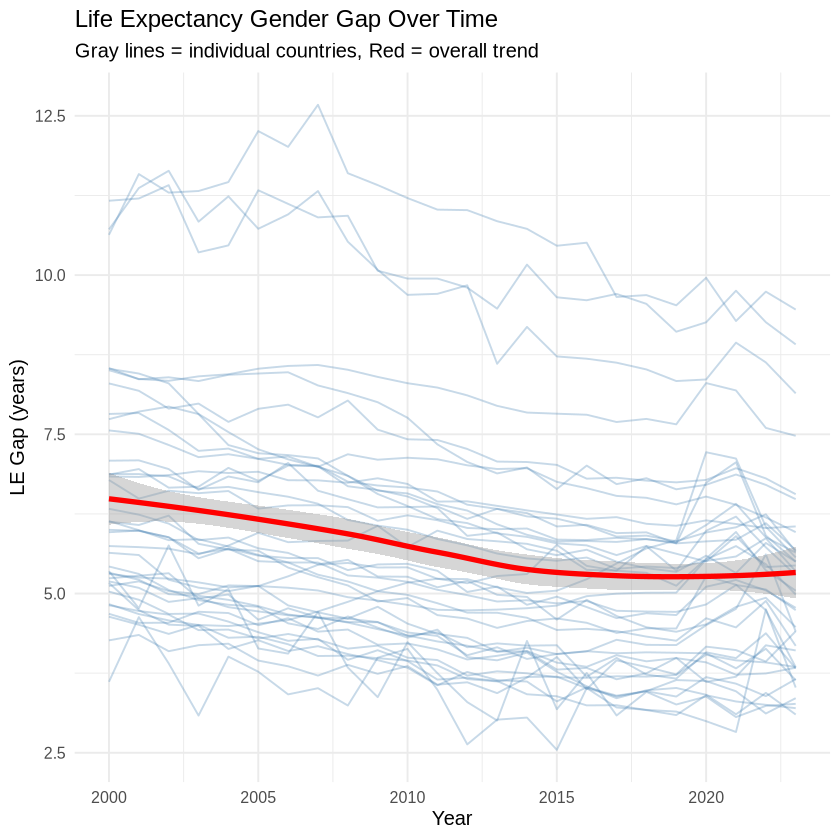

In [77]:
# Temporal trends by country
panel %>%
  ggplot(aes(x = Year, y = LE_gap, group = country)) +
  geom_line(alpha = 0.3, color = "steelblue") +
  geom_smooth(aes(group = 1), method = "loess", color = "red", linewidth = 1.5) +
  labs(
    title = "Life Expectancy Gender Gap Over Time",
    subtitle = "Gray lines = individual countries, Red = overall trend",
    x = "Year",
    y = "LE Gap (years)"
  )



|predictor               | correlation|
|:-----------------------|-----------:|
|Gap_UnintentionalInjury |       0.832|
|Gap_Suicide             |       0.795|
|Gap_Alcohol             |       0.633|
|Gap_RoadTraffic         |       0.577|
|Gap_LiverDisease        |       0.575|
|Gap_ChronicRespiratory  |       0.566|
|Gap_Neoplasms           |       0.536|
|Gap_Cardiovascular      |      -0.469|
|Gap_Diabetes            |      -0.379|
|Gap_Homicide            |       0.221|
|Gap_COVID               |       0.064|
|Gap_DrugDisorder        |       0.055|

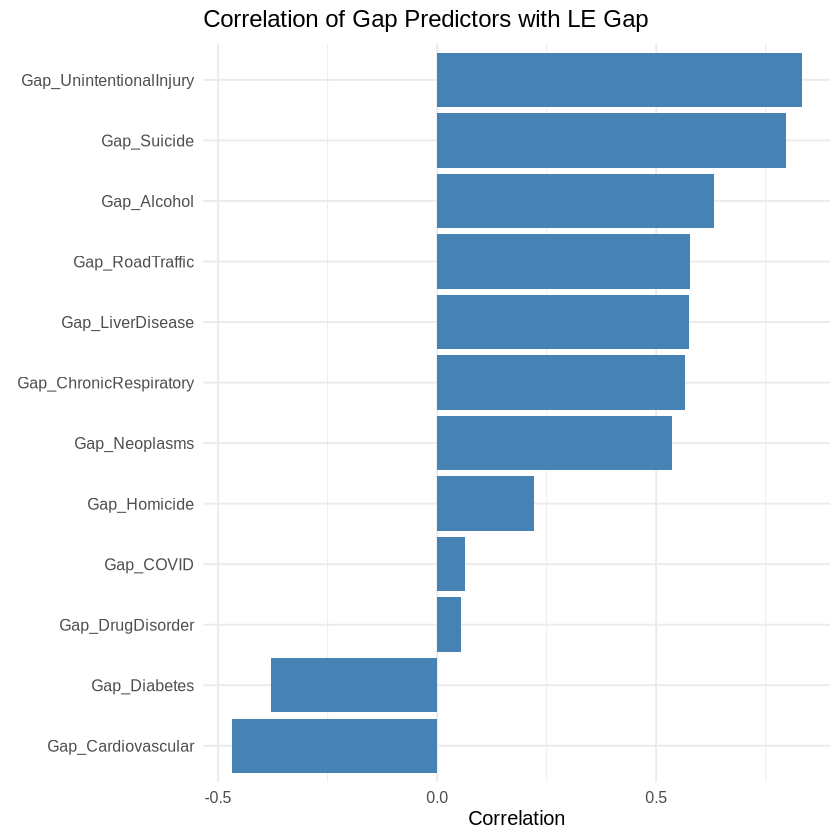

In [78]:
# Correlation of Gap predictors with target
gap_cols <- names(panel)[str_detect(names(panel), "^Gap_")]

correlations <- panel %>%
  select(all_of(gap_cols), LE_gap) %>%
  cor(use = "pairwise.complete.obs") %>%
  as.data.frame() %>%
  rownames_to_column("predictor") %>%
  filter(predictor != "LE_gap") %>%
  select(predictor, correlation = LE_gap) %>%
  arrange(desc(abs(correlation)))

correlations %>%
  ggplot(aes(x = reorder(predictor, correlation), y = correlation)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(
    title = "Correlation of Gap Predictors with LE Gap",
    x = NULL,
    y = "Correlation"
  )

# Print correlations table
correlations %>%
  knitr::kable(digits = 3)

# Model Specification

## Prepare Data

In [79]:
# Select predictors (Gap columns only, matching PyMC model)
gap_cols <- names(panel)[str_detect(names(panel), "^Gap_")]

# Create model data frame
model_data_raw <- panel %>%
  select(LE_gap, country, Year, all_of(gap_cols)) %>%
  drop_na()

log_and_print("Raw model data: %d observations, %d predictors", 
              nrow(model_data_raw), length(gap_cols))

Raw model data: 888 observations, 12 predictors 


In [80]:
# Explicit data preprocessing to match PyMC model:
# 1. Standardize predictors (mean=0, std=1, using population std ddof=0)
# 2. Center target variable (mean=0)

# Extract raw predictors and target
X_raw <- as.matrix(model_data_raw[, gap_cols])
y_raw <- model_data_raw$LE_gap

# Standardize predictors (matching PyMC: ddof=0 for population std)
X_mean <- colMeans(X_raw)
X_std <- apply(X_raw, 2, function(x) sqrt(mean((x - mean(x))^2)))  # Population std (ddof=0)
# Guard against zero variance columns
X_std_safe <- ifelse(X_std == 0, 1.0, X_std)
X_stdized <- sweep(sweep(X_raw, 2, X_mean, "-"), 2, X_std_safe, "/")

# Center target (matching PyMC)
# Note: Target is CENTERED (mean subtracted) but NOT STANDARDIZED (no division by SD)
y_mean <- mean(y_raw)
y_centered <- y_raw - y_mean

# Create preprocessed data frame
# Replace original predictor columns with standardized versions
model_data <- model_data_raw %>%
  mutate(LE_gap_centered = y_centered)

# Replace predictor columns with standardized versions (preserve column names)
X_stdized_df <- as.data.frame(X_stdized)
colnames(X_stdized_df) <- gap_cols  # Ensure column names match
model_data[gap_cols] <- X_stdized_df

# Verify column names are correct
log_and_print("\nVerifying standardized predictors in model_data:")
log_and_print("  Expected predictors: %s", paste(gap_cols, collapse=", "))
log_and_print("  Found in model_data: %s", paste(intersect(names(model_data), gap_cols), collapse=", "))
if (all(gap_cols %in% names(model_data))) {
  log_and_print("  ✓ All predictors found in model_data")
} else {
  log_and_print("  ✗ Missing predictors!")
}

# Store preprocessing parameters for later use (e.g., counterfactuals, Python comparison)
# These will be saved in Step 9e for Python comparison
# Note: X_std_safe contains the ORIGINAL (unstandardized) SDs, needed for feature importance
preprocessing_params <- list(
  X_mean = X_mean,
  X_std = X_std_safe,  # Original SDs (before standardization) - use for importance calculations
  y_mean = y_mean,
  predictors = gap_cols
)

log_and_print("\nPreprocessing complete:")
log_and_print("  Predictors standardized: mean=0, std=1 (population std)")
log_and_print("  Target centered: mean subtracted (%.3f years)", y_mean)
log_and_print("  Standardized predictor means: [%.3f, %.3f]", 
              min(colMeans(X_stdized)), max(colMeans(X_stdized)))
log_and_print("  Standardized predictor stds: [%.3f, %.3f]", 
              min(apply(X_stdized, 2, sd)), max(apply(X_stdized, 2, sd)))
log_and_print("  Centered target mean: %.6f years", mean(y_centered))


Verifying standardized predictors in model_data: 
  Expected predictors: Gap_Alcohol, Gap_Suicide, Gap_Homicide, Gap_RoadTraffic, Gap_Cardiovascular, Gap_Diabetes, Gap_Neoplasms, Gap_ChronicRespiratory, Gap_LiverDisease, Gap_UnintentionalInjury, Gap_DrugDisorder, Gap_COVID 
  Found in model_data: Gap_Alcohol, Gap_Suicide, Gap_Homicide, Gap_RoadTraffic, Gap_Cardiovascular, Gap_Diabetes, Gap_Neoplasms, Gap_ChronicRespiratory, Gap_LiverDisease, Gap_UnintentionalInjury, Gap_DrugDisorder, Gap_COVID 
  ✓ All predictors found in model_data 

Preprocessing complete: 
  Predictors standardized: mean=0, std=1 (population std) 
  Target centered: mean subtracted (5.723 years) 
  Standardized predictor means: [-0.000, 0.000] 
  Standardized predictor stds: [1.001, 1.001] 
  Centered target mean: 0.000000 years 


## Define Priors

In [81]:
# Priors matching PyMC model exactly:
# - Normal(0, 1) prior for predictor coefficients (beta)
# - Normal(0, 5) prior for intercept (mu_alpha)
# - HalfNormal(1) for random effect SD (sigma_alpha)
# - HalfNormal(1) for residual SD (sigma)

model_priors <- c(
  # Normal prior for predictor coefficients (matching PyMC: beta ~ Normal(0, 1))
  set_prior("normal(0, 1)", class = "b"),
  # Prior for intercept (matching PyMC: mu_alpha ~ Normal(0, 5))
  set_prior("normal(0, 5)", class = "Intercept"),
  # Prior for country random effect SD (matching PyMC: sigma_alpha ~ HalfNormal(1))
  set_prior("normal(0, 1)", class = "sd", lb = 0),
  # Prior for residual SD (matching PyMC: sigma ~ HalfNormal(1))
  set_prior("normal(0, 1)", class = "sigma", lb = 0)
)

## Fit Model

In [82]:
#| cache: true

# Build formula: LE_gap_centered ~ standardized_predictors + (1 | country)
# This matches the PyMC model structure:
#   mu = alpha[country_idx] + X_stdized @ beta
#   y_centered ~ Normal(mu, sigma)

# Note: model_data now contains standardized predictors (same column names)
# and centered target (LE_gap_centered)
predictor_formula <- paste(gap_cols, collapse = " + ")
model_formula <- as.formula(paste("LE_gap_centered ~", predictor_formula, "+ (1 | country)"))

log_and_print("Model formula:")
log_and_print(as.character(model_formula))
log_and_print("\nNote: Using standardized predictors and centered target to match PyMC model.")
print(model_formula)

# Fit the model
# Sampling parameters: using longer warmup to improve convergence
# iter=3000, warmup=2000 gives 1000 post-warmup draws per chain (same as before)
# Longer warmup should help with convergence (R-hat) and ESS
fit <- brm(
  model_formula,
  data = model_data,
  prior = model_priors,
  chains = 4,
  cores = 4,
  iter = 3000,      # Total iterations per chain
  warmup = 2000,    # Warmup iterations (longer warmup to improve convergence)
  seed = 42,
  backend = "cmdstanr",
  silent = 2,        # Suppress most output
  refresh = 500     # Print progress every 500 iterations
)

# Check if sampling completed successfully
if (nrow(as_draws_df(fit)) == 0) {
  stop("Model sampling failed - no posterior draws generated. Check Stan output above.")
}

log_and_print("\n%s", paste0(rep("=", 80), collapse = ""))
log_and_print("LIFE EXPECTANCY MODEL - SAMPLING COMPLETE")
log_and_print("%s", paste0(rep("=", 80), collapse = ""))
log_and_print("Total draws: %d (4 chains × %d draws per chain)", 
              nrow(as_draws_df(fit)),
              nrow(as_draws_df(fit)) / 4)

log_and_print("\n✓ Model sampling completed successfully")
log_and_print("  Total draws: %d (4 chains × %d draws per chain)", 
              nrow(as_draws_df(fit)),
              nrow(as_draws_df(fit)) / 4)
cat("\n✓ Model sampling completed successfully\n")
cat(sprintf("  Total draws: %d (4 chains × %d draws per chain)\n", 
            nrow(as_draws_df(fit)),
            nrow(as_draws_df(fit)) / 4))

Model formula: 
~ LE_gap_centered Gap_Alcohol + Gap_Suicide + Gap_Homicide + Gap_RoadTraffic + Gap_Cardiovascular + Gap_Diabetes + Gap_Neoplasms + Gap_ChronicRespiratory + Gap_LiverDisease + Gap_UnintentionalInjury + Gap_DrugDisorder + Gap_COVID + (1 | country) 

Note: Using standardized predictors and centered target to match PyMC model. 
LE_gap_centered ~ Gap_Alcohol + Gap_Suicide + Gap_Homicide + 
    Gap_RoadTraffic + Gap_Cardiovascular + Gap_Diabetes + Gap_Neoplasms + 
    Gap_ChronicRespiratory + Gap_LiverDisease + Gap_UnintentionalInjury + 
    Gap_DrugDisorder + Gap_COVID + (1 | country)

LIFE EXPECTANCY MODEL - SAMPLING COMPLETE 
Total draws: 4000 (4 chains × 1000 draws per chain) 

✓ Model sampling completed successfully 
  Total draws: 4000 (4 chains × 1000 draws per chain) 

✓ Model sampling completed successfully
  Total draws: 4000 (4 chains × 1000 draws per chain)


In [83]:
# Model summary
summary(fit)

 Family: gaussian 
  Links: mu = identity 
Formula: LE_gap_centered ~ Gap_Alcohol + Gap_Suicide + Gap_Homicide + Gap_RoadTraffic + Gap_Cardiovascular + Gap_Diabetes + Gap_Neoplasms + Gap_ChronicRespiratory + Gap_LiverDisease + Gap_UnintentionalInjury + Gap_DrugDisorder + Gap_COVID + (1 | country) 
   Data: model_data (Number of observations: 888) 
  Draws: 4 chains, each with iter = 3000; warmup = 2000; thin = 1;
         total post-warmup draws = 4000

Multilevel Hyperparameters:
~country (Number of levels: 37) 
              Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sd(Intercept)     0.65      0.09     0.50     0.84 1.00      973     1592

Regression Coefficients:
                        Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS
Intercept                   0.00      0.10    -0.20     0.21 1.00      580
Gap_Alcohol                 0.14      0.03     0.07     0.20 1.00     4230
Gap_Suicide                 0.36      0.04     0.28     0.45 1.00     3299
Gap_Hom

# Diagnostics

## Convergence

In [84]:
# Check R-hat values
rhat_vals <- rhat(fit)
cat(sprintf("Max R-hat: %.4f (should be < 1.01)\n", max(rhat_vals, na.rm = TRUE)))
cat(sprintf("Min R-hat: %.4f\n", min(rhat_vals, na.rm = TRUE)))

# Any problematic R-hat?
problematic <- rhat_vals[rhat_vals > 1.01]
if (length(problematic) > 0) {
  log_and_print("\nWarning: Parameters with R-hat > 1.01:")
  log_and_print(paste(names(problematic), collapse = ", "))
  print(problematic)
} else {
  log_and_print("\nAll R-hat values acceptable.")
}

Max R-hat: 1.0064 (should be < 1.01)
Min R-hat: 1.0000

All R-hat values acceptable. 


In [85]:
# Check effective sample size
neff_vals <- neff_ratio(fit)
min_ess <- min(neff_vals, na.rm = TRUE)
mean_ess <- mean(neff_vals, na.rm = TRUE)

log_and_print(paste("Min ESS ratio:", sprintf("%.2f", min_ess)))
log_and_print(paste("Mean ESS ratio:", sprintf("%.2f", mean_ess)))

log_and_print(sprintf("Min ESS ratio: %.2f", min_ess))
log_and_print(sprintf("Mean ESS ratio: %.2f", mean_ess))
cat(sprintf("Min ESS ratio: %.2f\n", min_ess))
cat(sprintf("Mean ESS ratio: %.2f\n", mean_ess))

Min ESS ratio: 0.15 
Mean ESS ratio: 0.34 
Min ESS ratio: 0.15 
Mean ESS ratio: 0.34 
Min ESS ratio: 0.15
Mean ESS ratio: 0.34


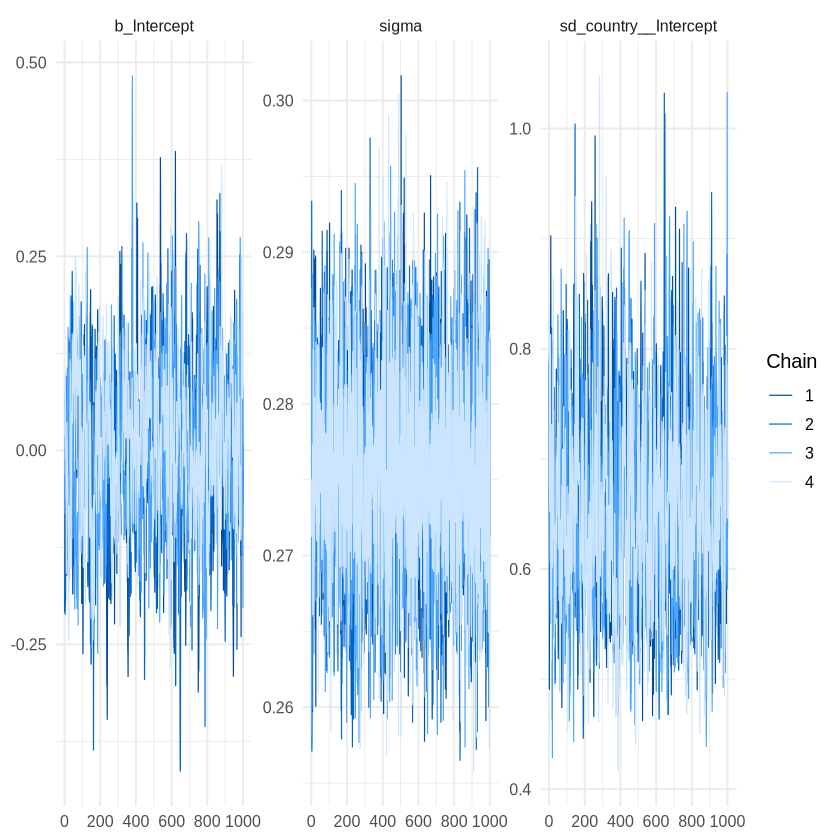

In [86]:
# Trace plots for key parameters
mcmc_trace(fit, pars = c("b_Intercept", "sigma", "sd_country__Intercept"))

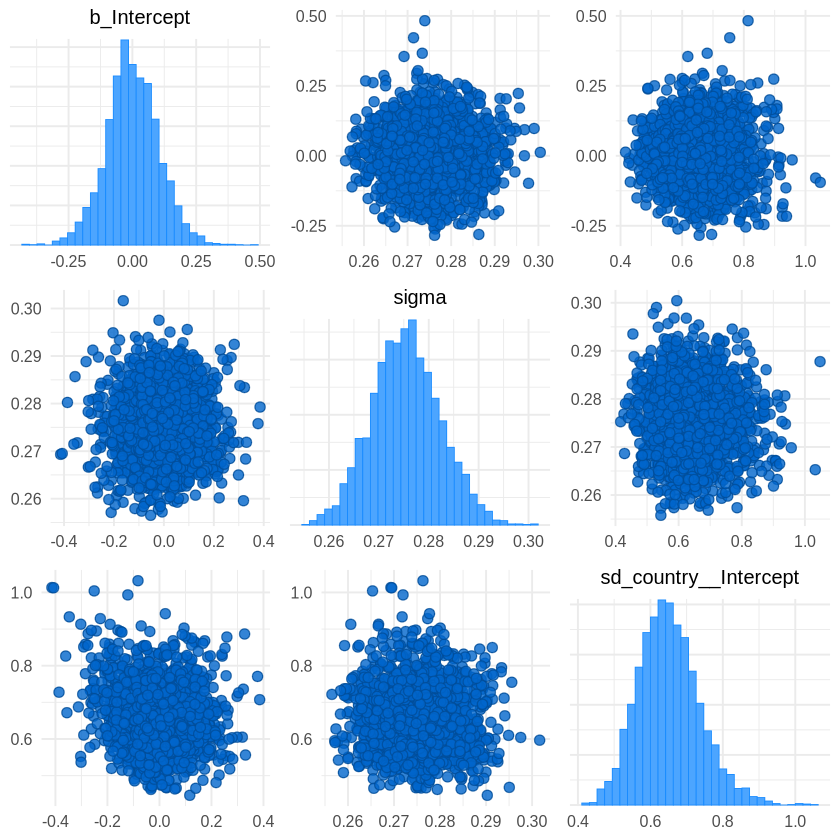

In [87]:
# Pairs plot for hyperparameters
mcmc_pairs(fit, pars = c("b_Intercept", "sigma", "sd_country__Intercept"))

## LOO Cross-Validation

In [88]:
# Compute LOO-CV
loo_fit <- loo(fit, save_psis = TRUE)
print(loo_fit)

Warning message:
“Found 1 observations with a pareto_k > 0.7 in model 'fit'. We recommend to set 'moment_match = TRUE' in order to perform moment matching for problematic observations. ”



Computed from 4000 by 888 log-likelihood matrix.

         Estimate   SE
elpd_loo   -143.9 32.7
p_loo        55.4  5.1
looic       287.8 65.3
------
MCSE of elpd_loo is NA.
MCSE and ESS estimates assume MCMC draws (r_eff in [0.4, 1.4]).

Pareto k diagnostic values:
                         Count Pct.    Min. ESS
(-Inf, 0.7]   (good)     887   99.9%   653     
   (0.7, 1]   (bad)        1    0.1%   <NA>    
   (1, Inf)   (very bad)   0    0.0%   <NA>    
See help('pareto-k-diagnostic') for details.



Pareto k diagnostics: 
  Max k: 0.773 
  Mean k: 0.088 
  k > 0.7: 1 (0.1%) 


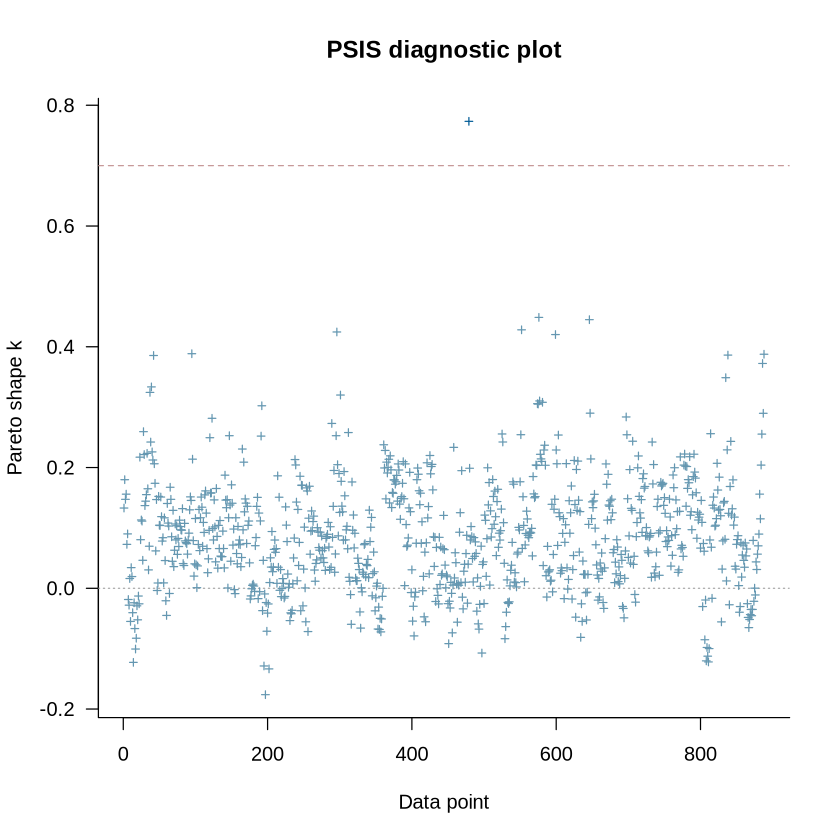

In [89]:
# Check Pareto k values
pareto_k <- loo_fit$diagnostics$pareto_k

log_and_print("\nPareto k diagnostics:")
log_and_print("  Max k: %.3f", max(pareto_k))
log_and_print("  Mean k: %.3f", mean(pareto_k))
log_and_print("  k > 0.7: %d (%.1f%%)", 
              sum(pareto_k > 0.7), 100 * mean(pareto_k > 0.7))

# Plot Pareto k values
plot(loo_fit)

## Posterior Predictive Checks

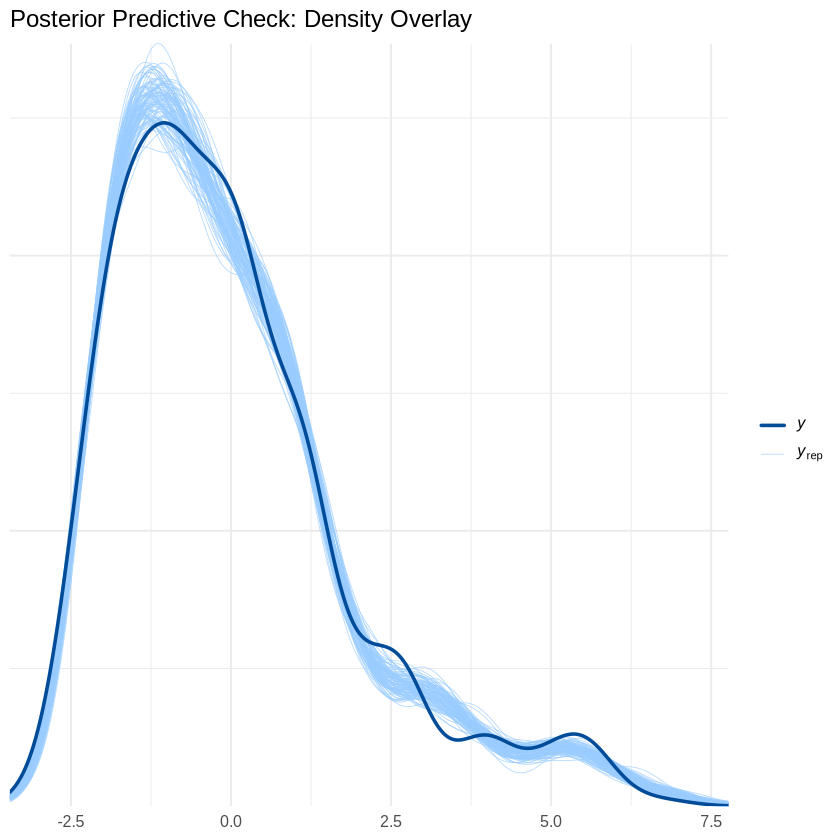

In [90]:
# Density overlay
pp_check(fit, ndraws = 100) +
  labs(title = "Posterior Predictive Check: Density Overlay")

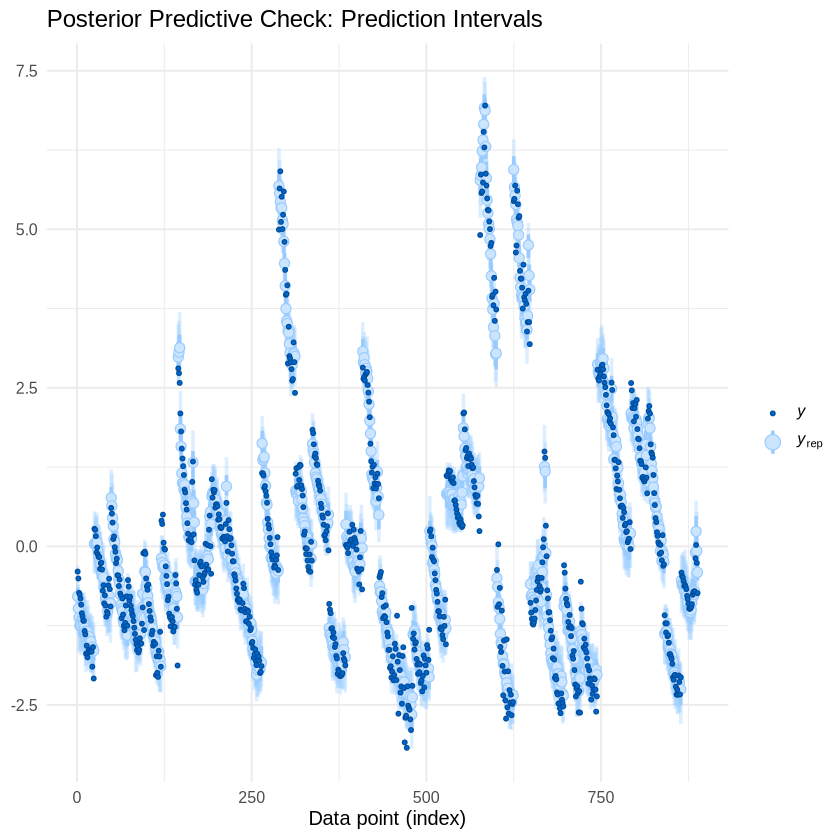

In [91]:
# Prediction intervals
pp_check(fit, type = "intervals", ndraws = 100) +
  labs(title = "Posterior Predictive Check: Prediction Intervals")

Using all posterior draws for ppc type 'stat' by default.

Note: in most cases the default test statistic 'mean' is too weak to detect anything of interest.

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
Using all posterior draws for ppc type 'stat' by default.

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


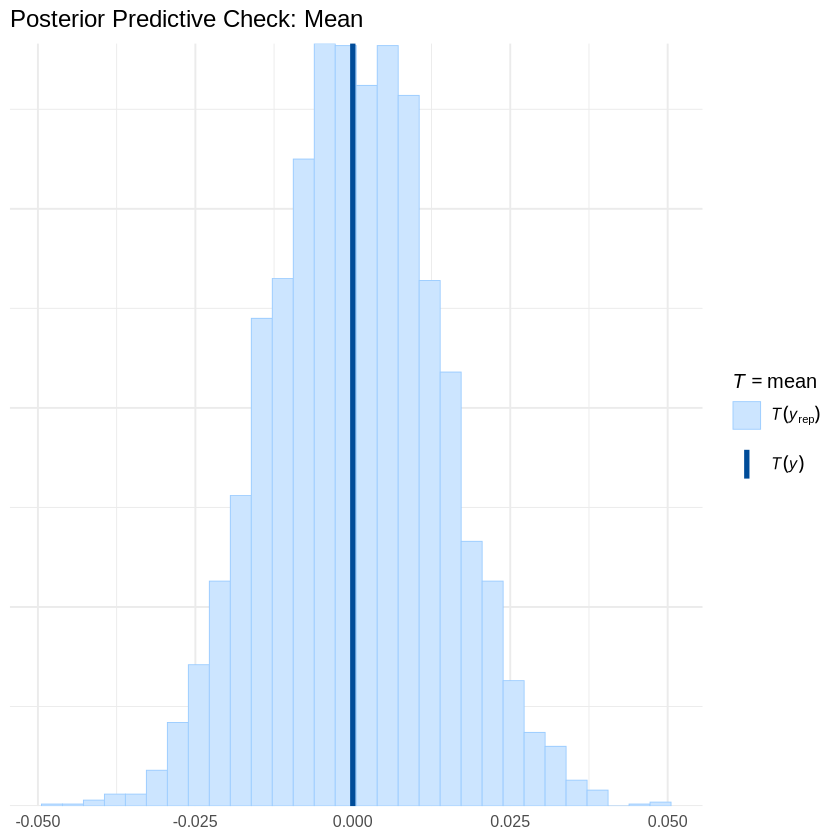

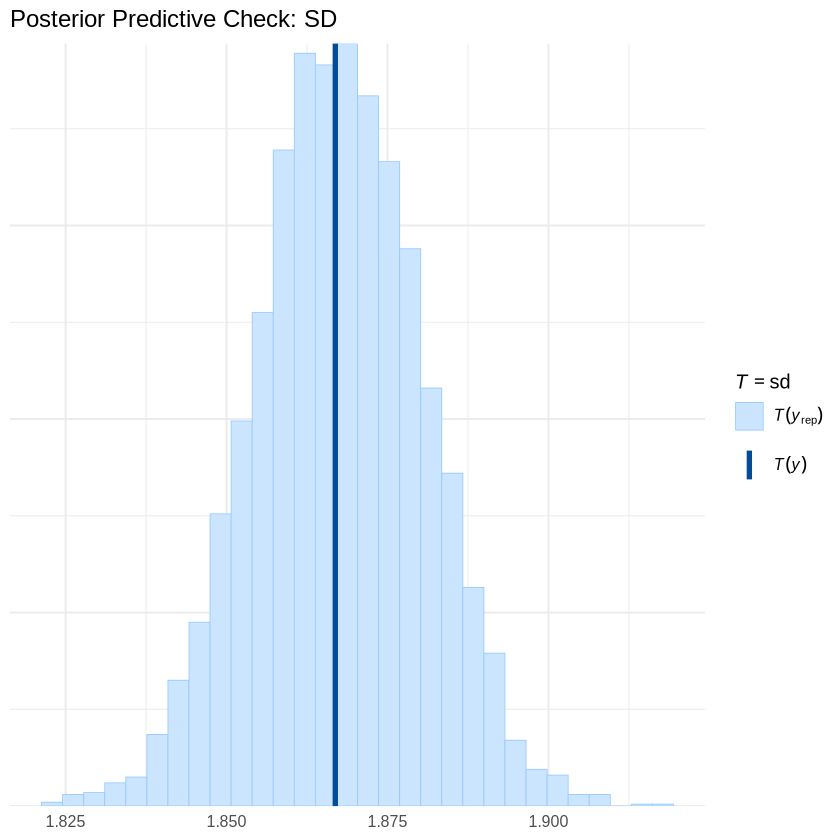

In [92]:
# Test statistics
pp_check(fit, type = "stat", stat = "mean") +
  labs(title = "Posterior Predictive Check: Mean")

pp_check(fit, type = "stat", stat = "sd") +
  labs(title = "Posterior Predictive Check: SD")

# Results

## Fixed Effects (Predictor Coefficients)



Table: Fixed Effects (Predictor Coefficients)

|term                    | Estimate| Est.Error|   Q2.5|  Q97.5|
|:-----------------------|--------:|---------:|------:|------:|
|Gap_RoadTraffic         |    0.446|     0.026|  0.396|  0.496|
|Gap_Homicide            |    0.441|     0.024|  0.394|  0.488|
|Gap_Suicide             |    0.365|     0.041|  0.285|  0.446|
|Gap_Neoplasms           |    0.314|     0.054|  0.206|  0.418|
|Gap_ChronicRespiratory  |    0.296|     0.038|  0.222|  0.374|
|Gap_LiverDisease        |    0.250|     0.032|  0.189|  0.311|
|Gap_Cardiovascular      |   -0.188|     0.028| -0.243| -0.133|
|Gap_UnintentionalInjury |    0.161|     0.039|  0.085|  0.238|
|Gap_Alcohol             |    0.138|     0.034|  0.071|  0.204|
|Gap_COVID               |    0.108|     0.010|  0.088|  0.128|
|Gap_Diabetes            |   -0.106|     0.024| -0.154| -0.058|
|Gap_DrugDisorder        |    0.091|     0.020|  0.053|  0.130|

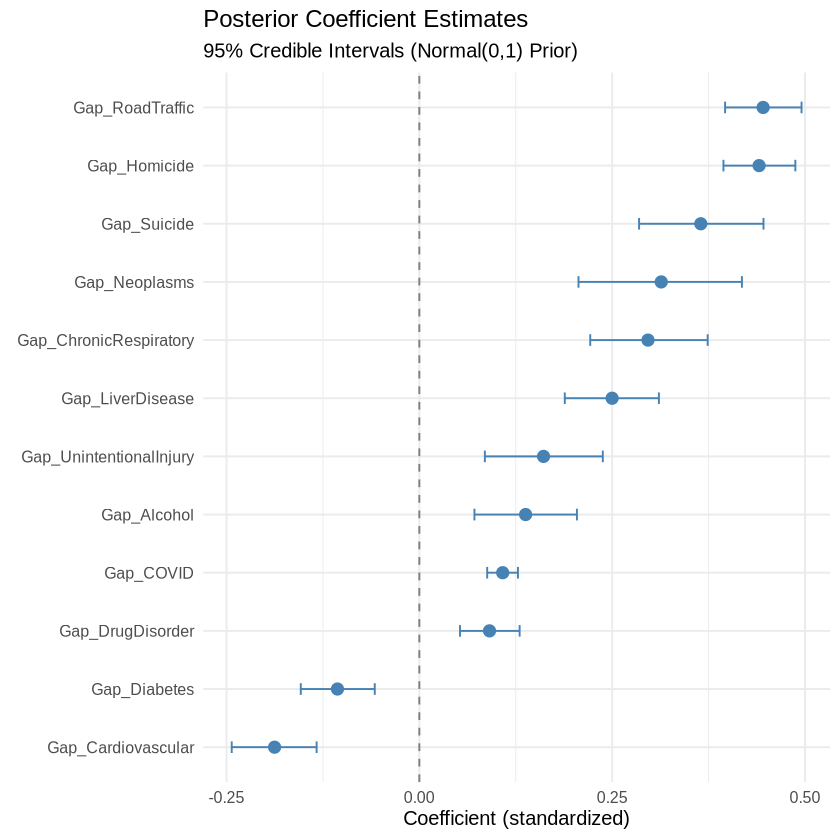

In [93]:
# Extract fixed effects
fixed_eff <- fixef(fit) %>%
  as.data.frame() %>%
  rownames_to_column("term") %>%
  filter(term != "Intercept") %>%
  arrange(desc(abs(Estimate)))

# Plot coefficients with credible intervals
fixed_eff %>%
  ggplot(aes(x = reorder(term, Estimate), y = Estimate)) +
  geom_point(size = 3, color = "steelblue") +
  geom_errorbar(aes(ymin = Q2.5, ymax = Q97.5), width = 0.2, color = "steelblue") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
  coord_flip() +
  labs(
    title = "Posterior Coefficient Estimates",
    subtitle = "95% Credible Intervals (Normal(0,1) Prior)",
    x = NULL,
    y = "Coefficient (standardized)"
  )

# Table
fixed_eff %>%
  knitr::kable(digits = 3, caption = "Fixed Effects (Predictor Coefficients)")

## Random Effects (Country Intercepts)



Table: Country Random Effects

|country | Estimate|   Q2.5|  Q97.5|
|:-------|--------:|------:|------:|
|EST     |    1.322|  0.946|  1.714|
|LVA     |    1.268|  0.909|  1.649|
|KOR     |    1.170|  0.917|  1.429|
|FRA     |    0.852|  0.595|  1.127|
|POL     |    0.779|  0.502|  1.068|
|SVK     |    0.713|  0.440|  0.994|
|LTU     |    0.695|  0.259|  1.135|
|JPN     |    0.635|  0.324|  0.951|
|FIN     |    0.475|  0.174|  0.760|
|IRL     |    0.424|  0.147|  0.686|
|ISL     |    0.401|  0.110|  0.675|
|CAN     |    0.104| -0.155|  0.357|
|DNK     |    0.097| -0.184|  0.373|
|CZE     |    0.019| -0.220|  0.262|
|ISR     |   -0.005| -0.296|  0.266|
|GBR     |   -0.013| -0.277|  0.233|
|USA     |   -0.033| -0.314|  0.247|
|NOR     |   -0.052| -0.306|  0.206|
|SWE     |   -0.145| -0.406|  0.105|
|GRC     |   -0.165| -0.500|  0.183|
|HUN     |   -0.196| -0.522|  0.123|
|AUS     |   -0.205| -0.447|  0.035|
|NZL     |   -0.225| -0.483|  0.025|
|CHE     |   -0.262| -0.499| -0.025|
|COL 

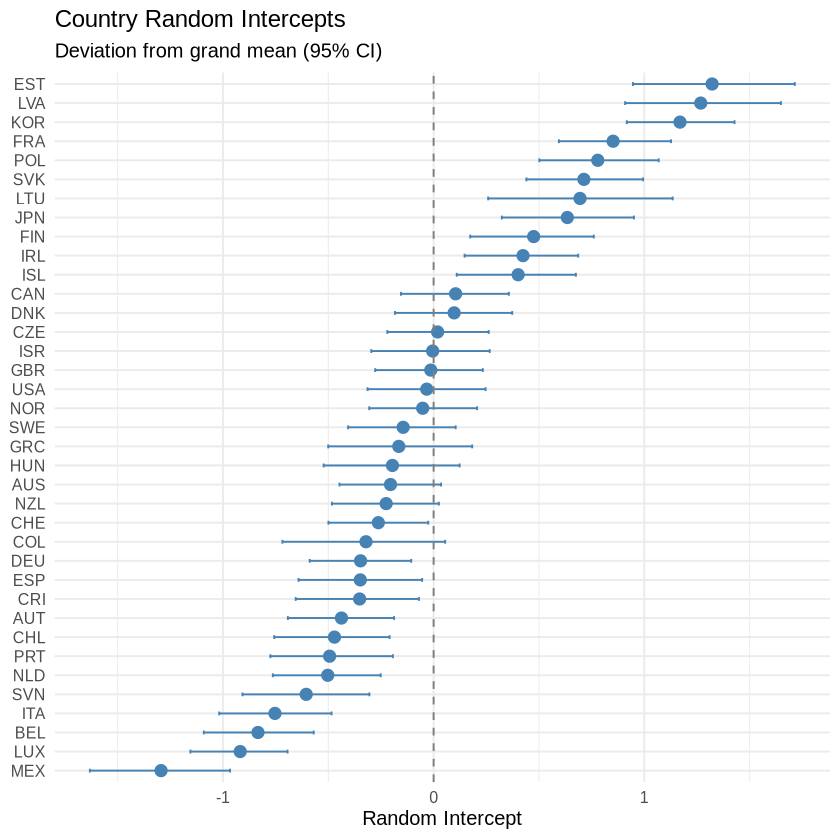

In [94]:
# Extract country random effects
country_effects <- ranef(fit)$country %>%
  as.data.frame() %>%
  rownames_to_column("country") %>%
  arrange(desc(Estimate.Intercept))

# Plot country intercepts
country_effects %>%
  ggplot(aes(x = reorder(country, Estimate.Intercept), y = Estimate.Intercept)) +
  geom_point(size = 3, color = "steelblue") +
  geom_errorbar(aes(ymin = Q2.5.Intercept, ymax = Q97.5.Intercept), 
                width = 0.2, color = "steelblue") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
  coord_flip() +
  labs(
    title = "Country Random Intercepts",
    subtitle = "Deviation from grand mean (95% CI)",
    x = NULL,
    y = "Random Intercept"
  )

# Table
country_effects %>%
  select(country, Estimate = Estimate.Intercept, 
         Q2.5 = Q2.5.Intercept, Q97.5 = Q97.5.Intercept) %>%
  knitr::kable(digits = 3, caption = "Country Random Effects")

## Feature Importance



Table: Feature Importance

|term                    |     sd| Estimate| importance|
|:-----------------------|------:|--------:|----------:|
|Gap_Neoplasms           | 38.167|    0.314|     11.971|
|Gap_Cardiovascular      | 36.911|   -0.188|      6.928|
|Gap_Homicide            | 13.468|    0.441|      5.933|
|Gap_Suicide             |  9.553|    0.365|      3.487|
|Gap_ChronicRespiratory  | 10.729|    0.296|      3.181|
|Gap_RoadTraffic         |  5.911|    0.446|      2.635|
|Gap_UnintentionalInjury | 15.214|    0.161|      2.450|
|Gap_LiverDisease        |  9.722|    0.250|      2.430|
|Gap_COVID               | 10.602|    0.108|      1.146|
|Gap_Alcohol             |  6.214|    0.138|      0.856|
|Gap_Diabetes            |  3.532|   -0.106|      0.375|
|Gap_DrugDisorder        |  2.786|    0.091|      0.254|

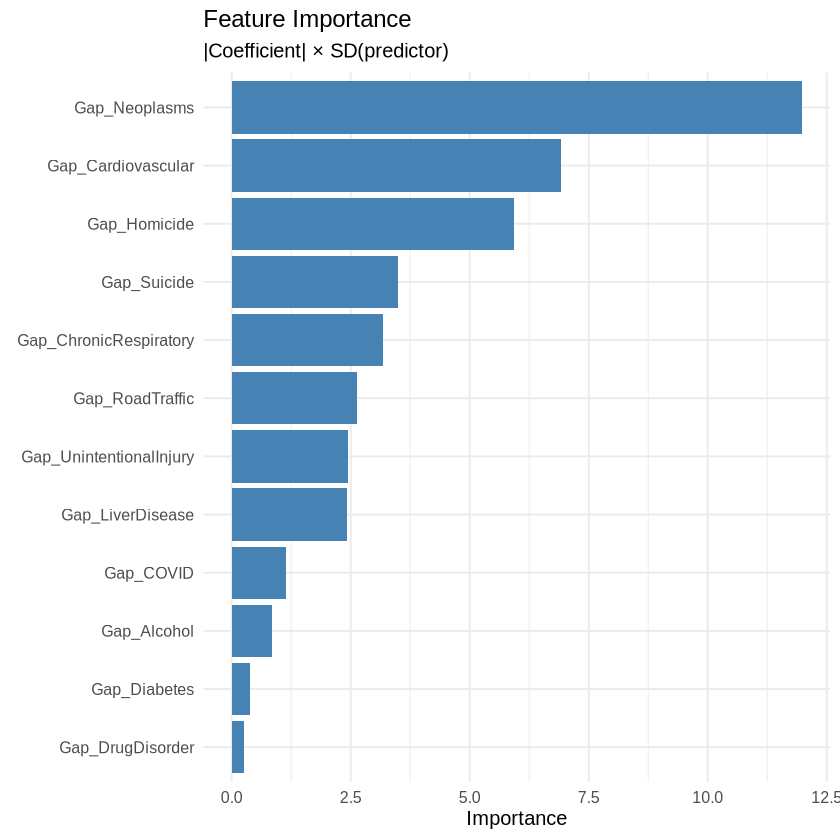

In [95]:
# Compute importance as |coefficient| × SD of predictor
# IMPORTANT: Use original (unstandardized) SDs, not SDs of standardized predictors
# The standardized predictors have SD ≈ 1, which would give incorrect importance
# We stored the original SDs in X_std_safe during preprocessing
predictor_sds <- tibble(
  term = gap_cols,
  sd = X_std_safe  # Original SDs (before standardization)
)

importance <- fixed_eff %>%
  left_join(predictor_sds, by = "term") %>%
  mutate(
    importance = abs(Estimate) * sd,
    importance_lower = abs(Q2.5) * sd,
    importance_upper = abs(Q97.5) * sd
  ) %>%
  arrange(desc(importance))

# Plot importance
importance %>%
  head(12) %>%
  ggplot(aes(x = reorder(term, importance), y = importance)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(
    title = "Feature Importance",
    subtitle = "|Coefficient| × SD(predictor)",
    x = NULL,
    y = "Importance"
  )

# Table
importance %>%
  select(term, sd, Estimate, importance) %>%
  knitr::kable(digits = 3, caption = "Feature Importance")

## R² and Model Fit

In [96]:
# Bayesian R²
r2 <- bayes_R2(fit)
log_and_print("Bayesian R²: %.3f (95%% CI: %.3f - %.3f)",
              mean(r2), quantile(r2, 0.025), quantile(r2, 0.975))

Bayesian R²: 0.734 (95% CI: 0.074 - 0.979) 


# Counterfactual Analysis

In [97]:
# Example: What if we reduced the suicide gap by 50%?

# Find country with highest suicide gap in 2019
high_suicide <- model_data %>%
  filter(Year == 2019) %>%
  slice_max(Gap_Suicide, n = 1)

log_and_print("Country with highest suicide gap (2019): %s", high_suicide$country)
log_and_print("Current Gap_Suicide: %.2f", high_suicide$Gap_Suicide)
log_and_print("Current LE_gap: %.2f years", high_suicide$LE_gap)

Country with highest suicide gap (2019): LTU 
Current Gap_Suicide: 2.48 
Current LE_gap: 9.53 years 


In [98]:
# Create counterfactual scenario (50% reduction in suicide gap)
counterfactual <- high_suicide %>%
  mutate(Gap_Suicide = Gap_Suicide * 0.5)

# Predict under both scenarios
pred_original <- posterior_predict(fit, newdata = high_suicide)
pred_counterfactual <- posterior_predict(fit, newdata = counterfactual)

# Compare distributions
log_and_print("\nPredicted LE gap:")
log_and_print("  Original: %.2f years (95%% CI: %.2f - %.2f)",
              mean(pred_original), 
              quantile(pred_original, 0.025), 
              quantile(pred_original, 0.975))
log_and_print("  Counterfactual: %.2f years (95%% CI: %.2f - %.2f)",
              mean(pred_counterfactual), 
              quantile(pred_counterfactual, 0.025), 
              quantile(pred_counterfactual, 0.975))
log_and_print("  Estimated reduction: %.2f years (95%% CI: %.2f - %.2f)",
              mean(pred_original - pred_counterfactual),
              quantile(pred_original - pred_counterfactual, 0.025),
              quantile(pred_original - pred_counterfactual, 0.975))


Predicted LE gap: 
  Original: 3.51 years (95% CI: 2.96 - 4.07) 
  Counterfactual: 3.05 years (95% CI: 2.46 - 3.61) 
  Estimated reduction: 0.46 years (95% CI: -0.31 - 1.22) 


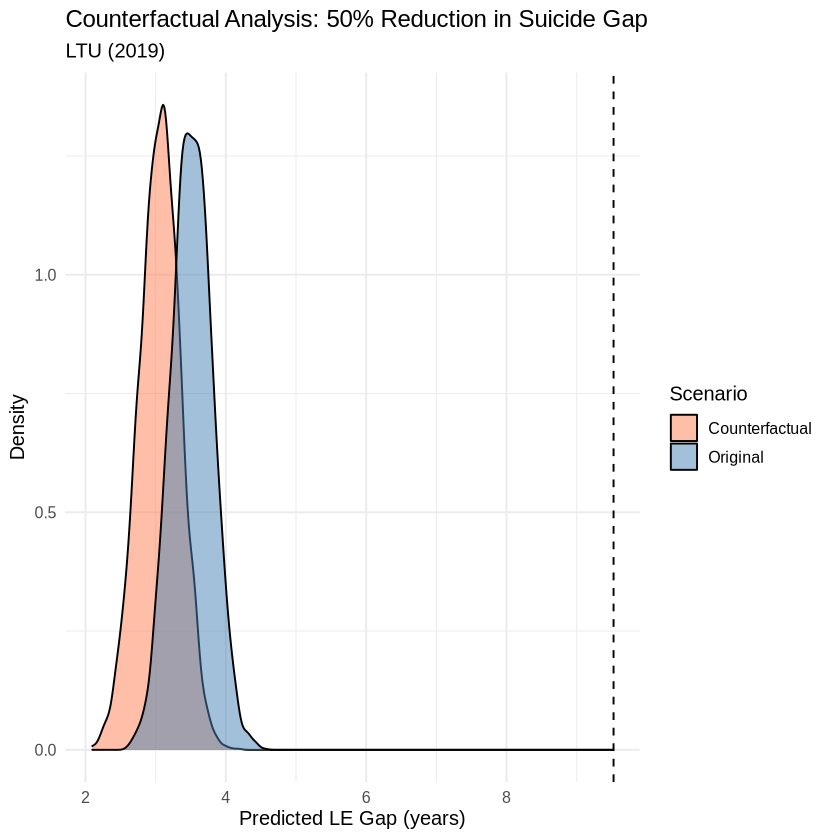

In [99]:
# Plot comparison
tibble(
  Scenario = c(rep("Original", length(pred_original)), 
               rep("Counterfactual", length(pred_counterfactual))),
  LE_gap = c(as.vector(pred_original), as.vector(pred_counterfactual))
) %>%
  ggplot(aes(x = LE_gap, fill = Scenario)) +
  geom_density(alpha = 0.5) +
  geom_vline(xintercept = high_suicide$LE_gap, linetype = "dashed", color = "black") +
  labs(
    title = "Counterfactual Analysis: 50% Reduction in Suicide Gap",
    subtitle = sprintf("%s (2019)", high_suicide$country),
    x = "Predicted LE Gap (years)",
    y = "Density"
  ) +
  scale_fill_manual(values = c("Original" = "steelblue", "Counterfactual" = "coral"))

# Comparison with PyMC Results

In [100]:
#| eval: false

# TODO: Load PyMC results and compare coefficients
# pymc_coefs <- read_csv("../output/tables/beta_coefficients_le_nomid_nogrw_y2023_covid.csv")

# comparison <- fixed_eff %>%
#   left_join(pymc_coefs, by = c("term" = "predictor"), suffix = c("_brms", "_pymc"))
# 
# comparison %>%
#   ggplot(aes(x = Estimate_pymc, y = Estimate_brms)) +
#   geom_point() +
#   geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
#   labs(
#     title = "Coefficient Comparison: brms vs PyMC",
#     x = "PyMC Estimate",
#     y = "brms Estimate"
#   )

# Save Results

In [101]:
# Create output directories if needed
dir.create("../data", showWarnings = FALSE, recursive = TRUE)
dir.create("../output/tables", showWarnings = FALSE, recursive = TRUE)

# Save model fit (RDS format - can be read by Python using pyreadr or rpy2)
saveRDS(fit, "../data/bayesian_model_brms_fit.rds")

# Save summary statistics (for quick reference)
write_csv(fixed_eff, "../output/tables/beta_coefficients_le_brms.csv")
write_csv(country_effects, "../output/tables/alpha_coefficients_le_brms.csv")
write_csv(importance, "../output/tables/importance_measures_le_brms.csv")

# Extract and save FULL posterior samples for Python comparison
# Convert to draws_df format (flattens chains × draws into single column)
draws_df <- as_draws_df(fit)

# Extract predictor coefficients (beta) - matching PyMC variable names
beta_samples <- draws_df %>%
  select(starts_with("b_"), -b_Intercept) %>%
  rename_with(~ str_remove(.x, "^b_"), everything())

# Get predictor names (remove "b_" prefix)
beta_cols <- names(beta_samples)
log_and_print("\nExtracting posterior samples:")
log_and_print("  Beta coefficients: %d predictors, %d draws", 
              length(beta_cols), nrow(beta_samples))

# Save beta samples (predictor coefficients)
write_csv(beta_samples, "../data/beta_samples_brms.csv")
log_and_print("  ✓ Saved: ../data/beta_samples_brms.csv")

# Extract country intercepts (alpha) - matching PyMC structure
# brms stores as r_country[country,Intercept], we need to pivot
alpha_samples_wide <- draws_df %>%
  select(starts_with("r_country["))

# Get country names from column names
alpha_cols <- names(alpha_samples_wide)
country_names <- str_extract(alpha_cols, "(?<=\\[)[^,]+(?=,)") %>% unique() %>% sort()

# Pivot to long format: draw, country, value
alpha_samples <- alpha_samples_wide %>%
  mutate(draw = row_number()) %>%
  pivot_longer(cols = -draw, names_to = "country_full", values_to = "alpha") %>%
  mutate(country = str_extract(country_full, "(?<=\\[)[^,]+(?=,)")) %>%
  select(draw, country, alpha) %>%
  pivot_wider(names_from = country, values_from = alpha) %>%
  select(-draw)

# Reorder columns to match country order
alpha_samples <- alpha_samples[, country_names]

log_and_print("  Country intercepts: %d countries, %d draws", 
              ncol(alpha_samples), nrow(alpha_samples))
write_csv(alpha_samples, "../data/alpha_samples_brms.csv")
log_and_print("  ✓ Saved: ../data/alpha_samples_brms.csv")

# Extract hyperparameters and residual SD
hyperparams <- draws_df %>%
  select(
    mu_alpha = b_Intercept,           # Grand mean (matching PyMC)
    sigma_alpha = sd_country__Intercept,  # Random effect SD (matching PyMC)
    sigma = sigma                      # Residual SD (matching PyMC)
  )

log_and_print("  Hyperparameters: %d draws", nrow(hyperparams))
write_csv(hyperparams, "../data/hyperparams_brms.csv")
log_and_print("  ✓ Saved: ../data/hyperparams_brms.csv")

# Save preprocessing parameters as JSON (for Python to read)
library(jsonlite)
preprocessing_json <- list(
  X_mean = as.list(setNames(X_mean, gap_cols)),
  X_std = as.list(setNames(X_std_safe, gap_cols)),
  y_mean = y_mean,
  predictors = gap_cols,
  n_observations = nrow(model_data),
  n_countries = length(unique(model_data$country)),
  n_years = length(unique(model_data$Year)),
  sampling_params = list(
    chains = 4,
    iter = 3000,
    warmup = 2000,
    draws_per_chain = 1000,
    total_draws = 4000
  )
)

write_json(preprocessing_json, "../data/preprocessing_params_brms.json", pretty = TRUE)
log_and_print("  ✓ Saved: ../data/preprocessing_params_brms.json")

log_and_print("\n✓ All results saved:")
log_and_print("  Summary tables: ../output/tables/")
log_and_print("  Full posterior samples: ../data/*_samples_brms.csv")
log_and_print("  Preprocessing params: ../data/preprocessing_params_brms.json")
log_and_print("  Model fit (RDS): ../data/bayesian_model_brms_fit.rds")
log_and_print("\nNote: CSV files can be read directly by Python pandas.")
log_and_print("      RDS file can be read using pyreadr or rpy2.")

Warning message:
“Dropping 'draws_df' class as required metadata was removed.”



Extracting posterior samples: 
  Beta coefficients: 12 predictors, 4000 draws 
  ✓ Saved: ../data/beta_samples_brms.csv 


Warning message:
“Dropping 'draws_df' class as required metadata was removed.”


  Country intercepts: 37 countries, 4000 draws 
  ✓ Saved: ../data/alpha_samples_brms.csv 


Warning message:
“Dropping 'draws_df' class as required metadata was removed.”


  Hyperparameters: 4000 draws 
  ✓ Saved: ../data/hyperparams_brms.csv 
  ✓ Saved: ../data/preprocessing_params_brms.json 

✓ All results saved: 
  Summary tables: ../output/tables/ 
  Full posterior samples: ../data/*_samples_brms.csv 
  Preprocessing params: ../data/preprocessing_params_brms.json 
  Model fit (RDS): ../data/bayesian_model_brms_fit.rds 

Note: CSV files can be read directly by Python pandas. 
      RDS file can be read using pyreadr or rpy2. 


# Session Info

In [102]:
sessionInfo()

R version 4.5.2 (2025-10-31)
Platform: x86_64-conda-linux-gnu
Running under: Linux Mint 20.3

Matrix products: default
BLAS/LAPACK: /home/downey/miniconda3/envs/LifeExpectancy/lib/libmkl_rt.so.2;  LAPACK version 3.12.1

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: America/New_York
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] jsonlite_2.0.0   patchwork_1.3.2  posterior_1.6.1  tidybayes_3.0.7 
 [5] loo_2.9.0        bayesplot_1.15.0 brms_2.23.0      Rcpp_1.1.1      
 [9] lubridate_1.9.4  forcats_1.0.1    stringr_1.6.0    dplyr_1.1.4     
[13] purrr_1.2.

# Cleanup

In [103]:
# Close log file
close_log_file()

Log file closed.
